In [1]:
from package_novqs import *

E0918 03:42:11.723347 1702893 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0918 03:42:11.735412 1702786 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


JAX device: [CudaDevice(id=0)]


# Model

## H4 chain

In [10]:
# generate Hamiltonian
model_name = "H4"
distance = 2.0 # 0.74 

geometry = [
    ('H', (0.0, 0.0, 0.0)),
    ('H', (0.0, 0.0, distance)),
    ('H', (0.0, 0.0, 2 * distance)),
    ('H', (0.0, 0.0, 3 * distance)),
]
molecule = MolecularData(geometry = geometry, 
                        basis = 'sto-3g',
                        multiplicity = 1,  # if n_electrons = odd, then multiplicity = 2; else multiplicity = 1
                        charge = 0,
                        data_directory = os.path.join(os.getcwd(), 'data'))
molecule = run_pyscf(molecule)
second_q_hamiltonian = molecule.get_molecular_hamiltonian(
                    #occupied_indices = [0, 1, 2, 3],  
                    #active_indices = [4, 5, 6, 7, 8, 9]  
                    )
jw_hamiltonian = jordan_wigner(second_q_hamiltonian)  
Ham = qml.import_operator(jw_hamiltonian)
H_mat = qml.matrix(Ham)
eigvals, eigvecs = jnp.linalg.eigh(H_mat)
Eg = eigvals[0]

In [2]:
distances = np.arange(0.1, 3.01, 0.01)
basis = 'sto-3g'
multiplicity = 1
charge = 0


results = {'distances': distances, 'HF': [], 'CISD': [], 'CCSD': [], 'CCSD(T)': [], 'FCI': []}

for dist in distances:
    geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, dist)), ('H', (0.0, 0.0, 2*dist)), ('H', (0.0, 0.0, 3*dist))]
    molecule = MolecularData(geometry, basis, multiplicity, charge, data_directory = os.path.join(os.getcwd(), 'data'))
    molecule = run_pyscf(molecule, run_scf=True, run_cisd=True, run_ccsd=True, run_fci=True)
    
    results['HF'].append(molecule.hf_energy)
    results['CISD'].append(molecule.cisd_energy)
    pyscf_ccsd = molecule._pyscf_data['ccsd']
    results['CCSD'].append(pyscf_ccsd.e_tot)
    results['CCSD(T)'].append(pyscf_ccsd.e_tot + pyscf_ccsd.ccsd_t())
    results['FCI'].append(molecule.fci_energy)


np.savez('data/H4_chain-scf_energies.npz', **results)

### Plot

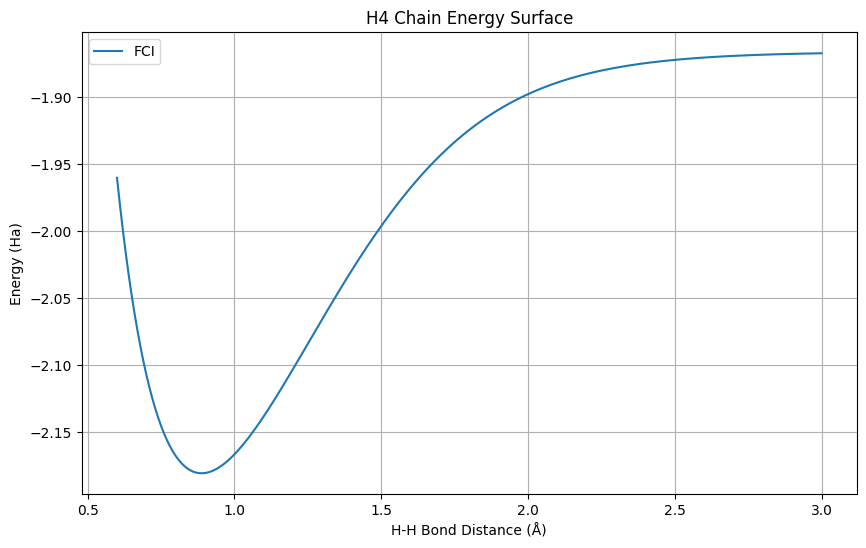

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# load data
with np.load('data/H4_chain-scf_energies.npz') as data: 
    dist = data['distances'][50:]
    hf = data['HF'][50:]
    cisd = data['CISD'][50:]
    ccsd = data['CCSD'][50:]
    ccsdt = data['CCSD(T)'][50:]
    fci = data['FCI'][50:]

# draw energy surface
step = 1
plt.figure(figsize=(10, 6))
#plt.plot(dist[::step], hf[::step], label='HF')
#plt.plot(dist[::step], cisd[::step], label='CISD')
#plt.plot(dist[::step], ccsd[::step], label='CCSD')
#plt.plot(dist[::step], ccsdt[::step], label='CCSD(T)')
plt.plot(dist[::step], fci[::step], label='FCI')
plt.xlabel('H-H Bond Distance (Å)')
plt.ylabel('Energy (Ha)')
plt.title('H4 Chain Energy Surface')
plt.legend()
plt.grid(True)
plt.show()

## H4 square

In [2]:
# generate Hamiltonian
model_name = "H4_square"
distance = 1.28  #1.28  # the equilibrium bond length for square H4
d = distance / 2  

# Coordinates of the H4 square geometry
geometry = [
    ('H', (-d, -d, 0.0)), # Bottom-left corner
    ('H', ( d, -d, 0.0)), # Bottom-right corner
    ('H', ( d,  d, 0.0)), # Top-right corner
    ('H', (-d,  d, 0.0)), # Top-left corner
]

molecule = MolecularData(geometry = geometry, 
                        basis = 'sto-3g',
                        multiplicity = 1,  # if n_electrons = odd, then multiplicity = 2; else multiplicity = 1
                        charge = 0,
                        data_directory = os.path.join(os.getcwd(), 'data'))
molecule = run_pyscf(molecule)
second_q_hamiltonian = molecule.get_molecular_hamiltonian()
jw_hamiltonian = jordan_wigner(second_q_hamiltonian)  

Ham = qml.import_operator(jw_hamiltonian)
H_mat = qml.matrix(Ham)
eigvals, eigvecs = jnp.linalg.eigh(H_mat)
Eg = eigvals[0]
print(Eg)

-1.97059584941926


In [3]:
# CAS(4e, 4o)：
n_electrons = 4
Nq = 8

# HF occupation vector: [1, 1, 1, 1, 0, ..., 0]
hf_state = qml.qchem.hf_state(n_electrons, Nq)

# Column 0 of eigvecs is the ground state
ground_state = eigvecs[:, 0]

# Convert the HF occupation bitstring to a computational-basis index
binary_weights = 2 ** np.arange(Nq - 1, -1, -1)
hf_index = int(np.dot(np.asarray(hf_state), binary_weights))

# Fidelity between the HF state and the exact ground state
fidelity = jnp.abs(jnp.abs(ground_state[hf_index])) ** 2

print("HF occupation vector:", hf_state)
print("HF basis index:", hf_index)
print("|<HF|Psi_g>|^2 =", fidelity)

HF occupation vector: [1 1 1 1 0 0 0 0]
HF basis index: 240
|<HF|Psi_g>|^2 = 0.4537499279788917


In [14]:
distances = np.arange(0.1, 3.01, 0.01)
basis = 'sto-3g'
multiplicity = 1
charge = 0


results = {'distances': distances, 'HF': [], 'CISD': [], 'CCSD': [], 'CCSD(T)': [], 'FCI': []}

for dist in distances:
    d = dist / 2 
    geometry = [('H', (-d, -d, 0.0)), ('H', ( d, -d, 0.0)), ('H', ( d,  d, 0.0)), ('H', (-d,  d, 0.0))]
    molecule = MolecularData(geometry, basis, multiplicity, charge, data_directory = os.path.join(os.getcwd(), 'data'))
    molecule = run_pyscf(molecule, run_scf=True, run_cisd=True, run_ccsd=True, run_fci=True)
    
    results['HF'].append(molecule.hf_energy)
    results['CISD'].append(molecule.cisd_energy)
    pyscf_ccsd = molecule._pyscf_data['ccsd']
    results['CCSD'].append(pyscf_ccsd.e_tot)
    results['CCSD(T)'].append(pyscf_ccsd.e_tot + pyscf_ccsd.ccsd_t())
    results['FCI'].append(molecule.fci_energy)


np.savez('data/H4_square-scf_energies.npz', **results)

### Plot

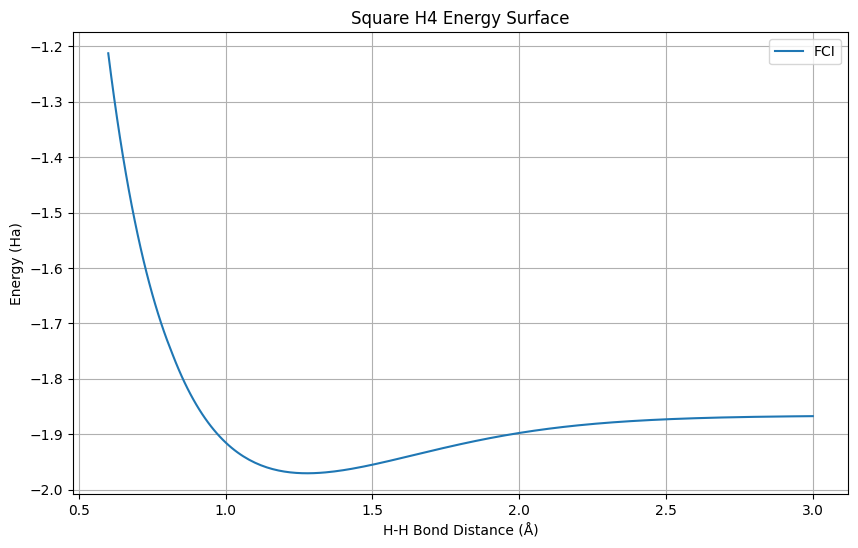

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# load data
with np.load('data/H4_square-scf_energies.npz') as data: 
    dist = data['distances'][50:]
    hf = data['HF'][50:]
    cisd = data['CISD'][50:]
    ccsd = data['CCSD'][50:]
    ccsdt = data['CCSD(T)'][50:]
    fci = data['FCI'][50:]

# draw energy surface
step = 1
plt.figure(figsize=(10, 6))
#plt.plot(dist[::step], hf[::step], label='HF')
#plt.plot(dist[::step], cisd[::step], label='CISD')
#plt.plot(dist[::step], ccsd[::step], label='CCSD')
#plt.plot(dist[::step], ccsdt[::step], label='CCSD(T)')
plt.plot(dist[::step], fci[::step], label='FCI')
plt.xlabel('H-H Bond Distance (Å)')
plt.ylabel('Energy (Ha)')
plt.title('Square H4 Energy Surface')
plt.legend()
plt.grid(True)
plt.show()

## N2

In [6]:
# generate Hamiltonian
model_name = "N2"
distance = 1.5  # Side length of the square

# Coordinates of the N2 geometry
geometry = [('N', (0.0, 0.0, 0.0)), 
            ('N', (0.0, 0.0, distance))
]

molecule = MolecularData(geometry = geometry, 
                        basis = 'sto-3g',
                        multiplicity = 1,  # if n_electrons = odd, then multiplicity = 2; else multiplicity = 1
                        charge = 0)
molecule = run_pyscf(molecule)
second_q_hamiltonian = molecule.get_molecular_hamiltonian(
                    occupied_indices = [0, 1, 2, 3],  
                    active_indices = [4, 5, 6, 7, 8, 9]  
                    )
jw_hamiltonian = jordan_wigner(second_q_hamiltonian)  
Ham = qml.import_operator(jw_hamiltonian)
H_mat = qml.matrix(Ham)
eigvals, eigvecs = jnp.linalg.eigh(H_mat)
Eg = eigvals[0]
print(Eg)

-107.55103503106704


# Ansatz

In [11]:
# 1. Prepare the input data 
n_orbits = 4
n_electrons = 4
Nq = n_orbits * 2

# 2. Instantiate the ansatz object
n_blocks = 2
n_layers = Nq // 2
ansatz = fSimAnsatz(Nq, n_blocks, n_layers)

# 3. Create the device and circuit
dev = qml.device("default.qubit", wires=Nq)
hf_state = qml.qchem.hf_state(n_electrons, Nq)
init_state = 'US' # uniform superposition state (US), Hartree Fock state (HF)
init_dist = 'Uniform'  # Gaussian, Uniform, Zeros, Perturbation
circuit = get_circuit(dev, ansatz, init_state, hf_state)
circuits_fn = jax.jit(jax.vmap(circuit, in_axes=(0,)))   # for multi ansatze

# 4. Initialize the parameters and run
print("--- Quantum circuit diagram ---")
params = init_params(Nq, n_blocks, n_layers, Ns=1, method=init_dist, seed=0)
print(qml.draw(circuit)(params))

--- Quantum circuit diagram ---
0: ──H─╭IsingXY(-0.33)─╭●─────────╭SWAP─────────────────────────────────╭IsingXY(0.41)─ ···
1: ──H─╰IsingXY(-0.33)─╰Rϕ(-0.57)─╰SWAP─╭IsingXY(0.14)─╭●─────────╭SWAP─╰IsingXY(0.41)─ ···
2: ──H─╭IsingXY(1.86)──╭●─────────╭SWAP─╰IsingXY(0.14)─╰Rϕ(-0.62)─╰SWAP─╭IsingXY(-0.81) ···
3: ──H─╰IsingXY(1.86)──╰Rϕ(0.15)──╰SWAP─╭IsingXY(1.42)─╭●─────────╭SWAP─╰IsingXY(-0.81) ···
4: ──H─╭IsingXY(0.13)──╭●─────────╭SWAP─╰IsingXY(1.42)─╰Rϕ(-0.88)─╰SWAP─╭IsingXY(-0.31) ···
5: ──H─╰IsingXY(0.13)──╰Rϕ(-0.29)─╰SWAP─╭IsingXY(0.57)─╭●─────────╭SWAP─╰IsingXY(-0.31) ···
6: ──H─╭IsingXY(1.53)──╭●─────────╭SWAP─╰IsingXY(0.57)─╰Rϕ(0.99)──╰SWAP─╭IsingXY(0.09)─ ···
7: ──H─╰IsingXY(1.53)──╰Rϕ(0.27)──╰SWAP─────────────────────────────────╰IsingXY(0.09)─ ···

0: ··· ─╭●─────────╭SWAP──────────────────────────────────╭IsingXY(-0.85)─╭●─────────╭SWAP ···
1: ··· ─╰Rϕ(-0.22)─╰SWAP─╭IsingXY(0.30)──╭●─────────╭SWAP─╰IsingXY(-0.85)─╰Rϕ(0.24)──╰SWAP ···
2: ··· ─╭●─────────╭SWAP─╰IsingXY(0.30)──

# VQS

In [4]:
# 3. Perform one evolution step (e.g., imaginary-time evolution)
params = init_params(Nq, n_blocks, n_layers, Ns=1, method=init_dist, seed=0)

# 2. Initialize the evolution solver
# H_mat is the previously generated Hamiltonian matrix
evolver = VariationalEvolver(circuit, H_mat, reg=1e-8)

psi0 = circuit(params)  # hf_state because params are set to 0s
eig_coeffs = eigvecs.conj().T @ psi0
#print(jnp.abs(eig_coeffs)**2)

In [5]:
# Simulation parameters
T = 5.0
dt = 0.005
n_steps = int(T / dt)

time_points = jnp.zeros(n_steps + 1)
trajectory = jnp.zeros((len(params), n_steps + 1))

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params)


# Time-stepping loop
for i in tqdm(range(n_steps), desc="Real Time Evolution"):
    t = i * dt
    params = rk4_step(evolver.theta_dot_rte, t, params, dt) # Only this step is accelerated

    time_points = time_points.at[i + 1].set(t + dt)    # Time points
    trajectory = trajectory.at[:, i + 1].set(params)   # Parameter trajectory shape=(n_params, n_time_points)

Real Time Evolution: 100%|██████████| 1000/1000 [00:19<00:00, 50.20it/s]


## Fidelity

In [6]:
# 2. Instantiate exactRTE
rte_solver = exactRTE(eigvals, eigvecs, eig_coeffs)

# 3. Instantiate FidelityCalculator and pass in solver
fid_calc = FidelityCalculator(circuit, rte_solver)

# 4. Batched calculation
# Note: if trajectory has shape (n_params, steps), transpose it to (steps, n_params)
params_all = trajectory.T
fidelities_vqs = fid_calc.compute_batched(params_all, time_points, batch_size=100)

Computing Fidelity: 100%|██████████| 11/11 [00:03<00:00,  2.90it/s]


## Save data

In [76]:
if not os.path.exists("data"):
    os.makedirs("data")

file_path = f"data/VQS-RTE-fidelities-{model_name}-dist={distance}-Nq={Nq}-T={T}-L={n_layers}-B={n_blocks}-{init_state}-{init_dist}.npy"

data_to_save = {
    "fidelities": fidelities_vqs,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

## Plot

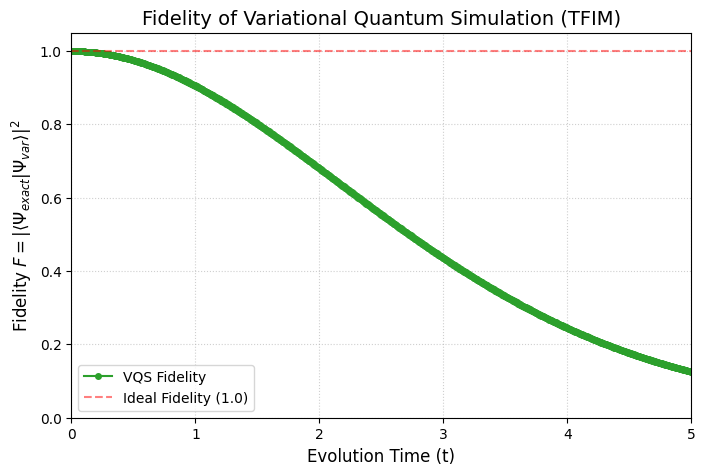

In [7]:
import matplotlib.pyplot as plt

def plot_fidelity(time_points, fidelities):
    plt.figure(figsize=(8, 5), dpi=100)
    
    # Plot the fidelity curve
    plt.plot(time_points, fidelities, 'o-', color='#2ca02c', label='VQS Fidelity', markersize=4)
    
    # Plot the ideal reference line (Fidelity = 1)
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Ideal Fidelity (1.0)')
    
    # Set the axis limits
    plt.ylim(0, 1.05)  # Extend slightly above 1.0 to keep the topmost points visible
    plt.xlim(time_points[0], time_points[-1])
    
    # Add axis labels and a title
    plt.xlabel('Evolution Time (t)', fontsize=12)
    plt.ylabel('Fidelity $F = |\\langle \\Psi_{exact} | \\Psi_{var} \\rangle|^2$', fontsize=12)
    plt.title('Fidelity of Variational Quantum Simulation (TFIM)', fontsize=14)
    
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')
    
    plt.show()

# Call the plotting function
plot_fidelity(time_points, fidelities_vqs)

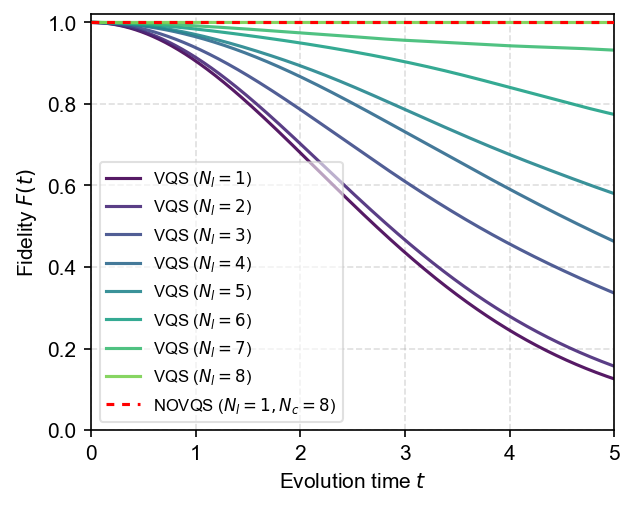

In [2]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# 1. Set the global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']  # 'Arial' 'Helvetica'  'Times New Roman'

distance = 2.0

# 1. Set the parameter range
n_blocks_list = list(range(1, 9))  # Generate [1, 2, 3, 4, 5, 6, 7, 8]
colors = cm.viridis(jnp.linspace(0, 0.8, len(n_blocks_list)))

fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)

# 1. Plot VQS (Single/Multi-block) curves
for i, nb in enumerate(n_blocks_list):
    file_path = f"data/VQS-RTE-fidelities-H4-dist={distance}-Nq=8-T=5.0-L=4-B={nb}-US-Uniform.npy"
    try:
        data = jnp.load(file_path, allow_pickle=True).item()
        fids_vqs = data['fidelities']
        t_pts = data['time_points']
        ax.plot(t_pts, fids_vqs, label=f'VQS ($N_l={nb}$)', color=colors[i], linewidth=1.5, alpha=0.9)
    except: continue

# 2. Plot and highlight the NOVQS curve
try:
    novqs_path = f"data/NOVQS-RTE-fidelities-H4-dist={distance}-Nq=8-T=5.0-L=4-B=1-Ns=8-US-Uniform.npy"
    novqs_data = jnp.load(novqs_path, allow_pickle=True).item()
    fids_novqs = novqs_data['fidelities']
    t_pts = data['time_points']
    ax.plot(t_pts, fids_novqs, color='red', ls=(0, (2.5, 2.5)), linewidth=1.5, label='NOVQS ($N_l=1, N_c=8$)', zorder=10)
except Exception as e:
    print(f"Could not load NOVQS data: {e}")


# 4. Format the main plot
#ax.axhline(y=1.0, color='black', linestyle=':', alpha=0.3)
ax.set_xlabel('Evolution time $t$', fontsize=10)
ax.set_ylabel('Fidelity $F(t)$', fontsize=10)
ax.set_ylim(0.0, 1.02)
ax.set_xlim(0, 5.0)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(loc='lower left', fontsize=8, framealpha=0.6) 
ax.grid(True, linestyle='--', alpha=0.4)


#plt.savefig(f"fig/H4-dist={distance}-fidelity-comparison.pdf", bbox_inches='tight')
plt.show()

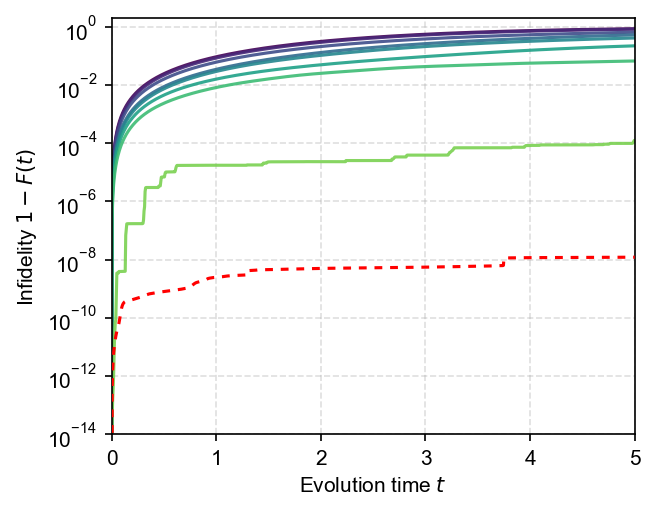

In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

distance = 2.0

# 1. Set the parameter range
n_blocks_list = list(range(1, 9))  # Generate [1, 2, 3, 4, 5, 6, 7, 8]
colors = cm.viridis(jnp.linspace(0, 0.8, len(n_blocks_list)))

fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)

# 1. Plot VQS (Single/Multi-block) curves
for i, nb in enumerate(n_blocks_list):
    file_path = f"data/VQS-RTE-fidelities-H4-dist={distance}-Nq=8-T=5.0-L=4-B={nb}-US-Uniform.npy"
    try:
        data = jnp.load(file_path, allow_pickle=True).item()
        fids_vqs = data['fidelities']
        t_pts = data['time_points']
        ax.plot(t_pts, 1 - fids_vqs, label=f'VQS ($N_l={nb}$)', color=colors[i], linewidth=1.5, alpha=0.9)
    except: continue

# 2. Plot and highlight the NOVQS curve
try:
    novqs_path = f"data/NOVQS-RTE-fidelities-H4-dist={distance}-Nq=8-T=5.0-L=4-B=1-Ns=8-US-Uniform.npy"
    novqs_data = jnp.load(novqs_path, allow_pickle=True).item()
    fids_novqs = novqs_data['fidelities']
    t_pts = data['time_points']
    ax.plot(t_pts, 1 - fids_novqs, color='red', ls=(0, (2.5, 2.5)), linewidth=1.5, label='NOVQS ($N_l=1, n=8$)', zorder=10)
except Exception as e:
    print(f"Could not load NOVQS data: {e}")


# 4. Format the main plot
ax.set_yscale('log')
#ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Evolution time $t$', fontsize=10)
ax.set_ylabel('Infidelity $1 - F(t)$', fontsize=10)
ax.set_ylim(1e-14, 2)
ax.set_xlim(0, 5.0)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.4)


#plt.savefig(f"fig/H4-dist={distance}-error-comparison.pdf", bbox_inches='tight')
plt.show()

# ITE-VQS

In [5]:
# 3. Perform one evolution step (e.g., imaginary-time evolution)
params = init_params(Nq, n_blocks, n_layers, Ns=1, method=init_dist, seed=42)

# 2. Initialize the evolution solver
# H_mat is the previously generated Hamiltonian matrix
evolver = VariationalEvolver(circuit, H_mat, reg=1e-8)

psi0 = circuit(params)  # hf_state because params are set to 0s
eig_coeffs = eigvecs.conj().T @ psi0
print(jnp.abs(eig_coeffs)**2)

[4.53749925e-01 5.37350397e-32 9.42697104e-34 8.71569460e-34
 3.88420423e-01 1.52953866e-33 4.04394161e-34 8.17922135e-33
 6.54451310e-33 5.69044048e-31 4.03785540e-33 2.77669114e-09
 3.45955289e-35 3.50400447e-33 1.78990295e-34 7.06477911e-33
 2.11313529e-34 1.20269442e-33 5.77036781e-34 7.37113069e-35
 6.57751471e-34 2.01908208e-33 4.52436288e-34 3.32085484e-35
 7.43694610e-32 3.40506339e-32 1.10775986e-35 4.03758376e-33
 1.09820965e-32 3.91902862e-33 3.18212814e-33 7.16853897e-36
 2.19857296e-32 1.67115603e-33 1.44250099e-33 1.99884942e-33
 3.10053516e-33 5.35116219e-33 3.67016290e-33 1.11132637e-32
 5.31489356e-34 4.20369130e-33 3.93873941e-34 5.35689900e-33
 8.16237490e-34 2.97910513e-33 4.68152077e-31 2.99431637e-34
 1.16919785e-33 1.00225059e-01 4.25716045e-34 3.95608085e-33
 8.96866194e-34 5.95131054e-32 1.15301473e-34 1.21509055e-32
 6.62910615e-34 3.73859502e-33 2.74697155e-33 4.88545969e-33
 4.11798314e-32 1.08694224e-33 3.20632667e-37 2.61437997e-32
 7.70411672e-34 1.716337

In [403]:
# Simulation parameters
T = 20.0
dt = 0.005
n_steps = int(T / dt)

time_points = jnp.zeros(n_steps + 1)
trajectory = jnp.zeros((len(params), n_steps + 1))

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params)



# Time-stepping loop
for i in tqdm(range(n_steps), desc="Imaginary Time Evolution"):
    t = i * dt
    params = rk4_step(evolver.theta_dot_ite, t, params, dt) # Only this step is accelerated

    time_points = time_points.at[i + 1].set(t + dt)    # Time points
    trajectory = trajectory.at[:, i + 1].set(params)   # Parameter trajectory shape=(n_params, n_time_points)

Imaginary Time Evolution:   0%|          | 0/4000 [00:00<?, ?it/s]

Imaginary Time Evolution: 100%|██████████| 4000/4000 [01:06<00:00, 59.79it/s] 


## Energies

In [404]:
# 2. Instantiate exactITE
ite_solver = exactITE(eigvals, eigvecs, eig_coeffs)

# 3. Instantiate FidelityCalculator and pass in solver
energy_calc = EnergyCalculator(circuit, ite_solver, H_mat)

# 4. Batched calculation
# Note: if trajectory has shape (n_params, steps), transpose it to (steps, n_params)
params_all = trajectory.T
energies_vqs, energies_ite = energy_calc.compute_batched(trajectory.T, time_points, batch_size=100)

Computing Energy: 100%|██████████| 41/41 [00:04<00:00, 10.07it/s]


## Save data

In [405]:
if not os.path.exists("data"):
    os.makedirs("data")
file_path = f"data/VQS-ITE-energies-{model_name}-dist={distance}-Nq={Nq}-T={T}-L={n_layers}-B={n_blocks}-{init_state}-{init_dist}.npy"

data_to_save = {
    "energies_vqs": energies_vqs,
    "energies_ite": energies_ite,
    "Eg": Eg,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

## Plot

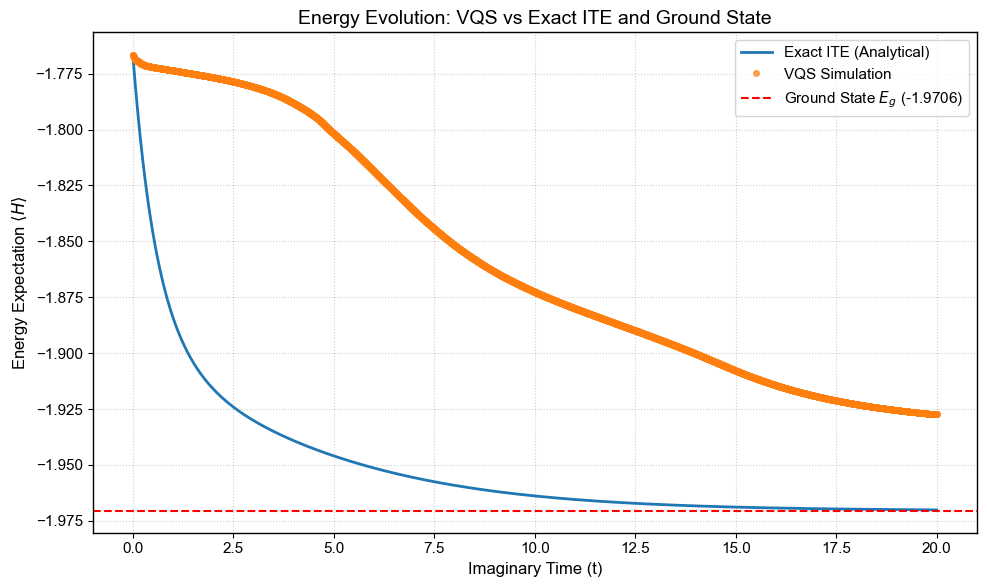

In [406]:
import matplotlib.pyplot as plt

def plot_energy_comparison(time_points, energies_vqs, energies_ite, Eg):
    plt.figure(figsize=(10, 6), dpi=100)
    
    # 1. Plot the exact ITE energy curve as the main reference
    plt.plot(time_points, energies_ite, '-', color='#1f77b4', linewidth=2, label='Exact ITE (Analytical)')
    
    # 2. Plot the VQS energy points to assess agreement with the reference
    plt.plot(time_points, energies_vqs, 'o', color='#ff7f0e', markersize=4, alpha=0.7, label='VQS Simulation')
    
    # 3. Plot the theoretical ground-state energy (E_g) reference line
    plt.axhline(y=Eg, color='r', linestyle='--', linewidth=1.5, label=f'Ground State $E_g$ ({Eg:.4f})')
    
    # Add axis labels and a title
    plt.xlabel('Imaginary Time (t)', fontsize=12)
    plt.ylabel('Energy Expectation $\\langle H \\rangle$', fontsize=12)
    plt.title('Energy Evolution: VQS vs Exact ITE and Ground State', fontsize=14)
    
    # Format the plot
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True)
    
    # Adjust the layout automatically to prevent labels from being clipped
    plt.tight_layout()
    plt.show()

# Call the plotting function (assuming energies_vqs, energies_ite, and E_ground have been computed)
plot_energy_comparison(time_points, energies_vqs, energies_ite, Eg)

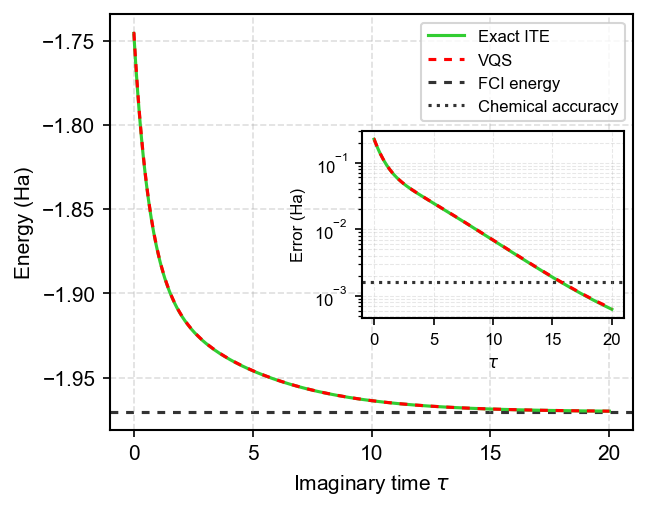

In [337]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1. Set the global plot style (consistent with the existing code)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.0

# Example input data (replace with your own data for actual use)
# time_points, energies_vqs, energies_ite, Eg
#file_path = f"data/VQS-ITE-energies-H4_square-dist=1.28-Nq=8-T=20.0-L=4-B={n_blocks}-HF-Perturbation.npy"
file_path = "data/VQS-ITE-energies-H4_square-dist=1.28-Nq=8-T=20.0-L=4-B=3-HF-Perturbation.npy"
data = jnp.load(file_path, allow_pickle=True).item()
energies_vqs = data['energies_vqs']
energies_ite = data['energies_ite']
time_points = data['time_points']


# Calculate the errors
error_vqs = jnp.abs(energies_vqs - Eg)
error_ite = jnp.abs(energies_ite - Eg)

# 2. Create the figure (4.5x3.6, matching the existing code)
fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)

# 3. Main plot: energy evolution

# Plot Exact ITE (solid line)
line_ite = ax.plot(time_points, energies_ite, '-', color='limegreen', linewidth=1.5, 
        label='Exact ITE')

# Plot VQS (points or a thin line; a line is recommended for a consistent style)
line_vqs = ax.plot(time_points, energies_vqs, ls=(0, (2.5, 2.5)), color='red', linewidth=1.5, 
        label='VQS')

# Plot the ground-state energy reference line (red dashed line, matching the NOVQS style)
line_gs = ax.axhline(y=Eg, color='black', ls=(0, (2.5, 2.5)), linewidth=1.5, label='FCI energy', alpha=0.8, zorder=1)

# 4. Format the main plot (match ticks, labels, and font sizes)
ax.set_xlabel('Imaginary time $\\tau$', fontsize=10)
ax.set_ylabel('Energy (Ha)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# ==========================================
# 5. Add an inset showing the error on a logarithmic scale
# ==========================================
# Relative position [left, bottom, width, height]; place near the lower left to avoid the upper-right legend
ax_ins = ax.inset_axes([0.482, 0.27, 0.5, 0.45])

# Chemical-accuracy reference line

ax_ins.semilogy(time_points, error_ite, '-', color='limegreen', linewidth=1.5)
ax_ins.semilogy(time_points, error_vqs, ls=(0, (2.5, 2.5)), color='red', linewidth=1.5)

line_ca = ax_ins.axhline(y=1.6e-3, color='black', linestyle=':', linewidth=1.5, label='Chemical accuracy', alpha=0.8, zorder=1)

# Format the inset
ax_ins.set_xlabel('$\\tau$', fontsize=8)
ax_ins.set_ylabel('Error (Ha)', fontsize=8)
ax_ins.tick_params(axis='both', which='major', labelsize=8)
ax_ins.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# 1. Get all legend handles and labels from the main plot
handles, labels = ax.get_legend_handles_labels()
handles.append(line_ca)
labels.append('Chemical accuracy')
ax.legend(handles=handles, labels=labels, handlelength=2.2, loc='upper right', fontsize=8)

# 6. Save and display
#plt.savefig(f"fig/H4-dist={distance}-energy-evolution.pdf", bbox_inches='tight')
plt.show()


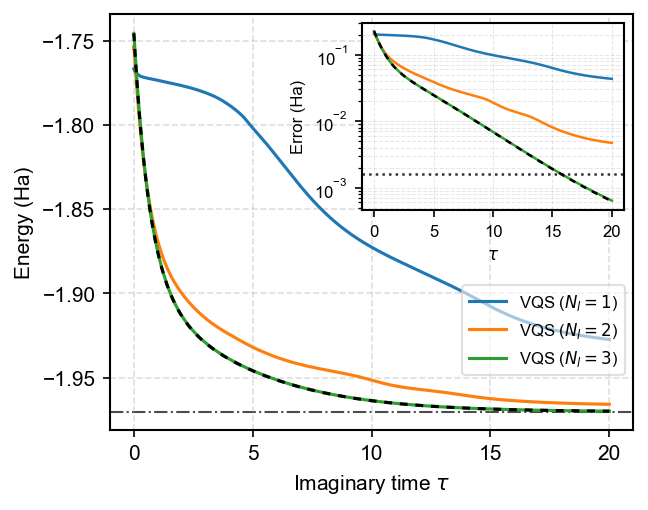

In [4]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import math

# 1. Set the global plot style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.0

# Parameter settings
n_blocks_list = [1, 2, 3]
# Generate a color gradient based on the number of blocks (dark to light green, or use shades of blue)
tab10 = plt.colormaps["tab10"]
colors = [
    tab10(i)
    for i in range(len(n_blocks_list))
]

# 2. Create the figure
fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)

# 5. Create the inset before the loop so data can be plotted in it during the loop
ax_ins = ax.inset_axes([0.482, 0.53, 0.5, 0.45])


# 3. Load and plot data for each value of B
for i, nb in enumerate(n_blocks_list):
    file_path = f"data/VQS-ITE-energies-H4_square-dist=1.28-Nq=8-T=20.0-L=4-B={nb}-HF-Perturbation.npy"
    
    data = jnp.load(file_path, allow_pickle=True).item()
    energies_vqs = data['energies_vqs']
    energies_ite = data['energies_ite']
    time_points = data['time_points']
    Eg = data['Eg'] 
    
    # Calculate the errors
    error_vqs = jnp.abs(energies_vqs - Eg)
    error_ite = jnp.abs(energies_ite - Eg)

    # --- Draw the main plot ---
    # Plot VQS for different values of B (dashed lines)
    ax.plot(time_points, energies_vqs, '-', color=colors[i], 
            linewidth=1.5, label=f'VQS ($N_l={nb}$)')

    # --- Draw the inset ---
    ax_ins.semilogy(time_points, error_vqs, ls='-', color=colors[i], linewidth=1.2)

    # Plot Exact ITE once, at the end
    if nb == n_blocks_list[-1]:
        ax.plot(time_points, energies_ite, ls=(0, (2.5, 2.5)), color='black', 
                            linewidth=1.5, zorder=2)
        # Also plot the exact error once in the inset
        ax_ins.semilogy(time_points, error_ite, ls=(0, (2.5, 2.5)), color='black', linewidth=1.2)


# Plot the ground-state energy reference line (black dash-dot line)
ax.axhline(y=Eg, color='black', ls='-.', linewidth=1.0, alpha=0.7, zorder=1)

# Plot the chemical-accuracy reference line in the inset
ax_ins.axhline(y=1.6e-3, color='black', linestyle=':', linewidth=1.2, alpha=0.8)

# 4. Format the main plot
ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xlabel('Imaginary time $\\tau$', fontsize=10)
ax.set_ylabel('Energy (Ha)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# Format the inset
ax_ins.set_xlabel('$\\tau$', fontsize=8)
ax_ins.set_ylabel('Error (Ha)', fontsize=8)
ax_ins.tick_params(axis='both', which='major', labelsize=8)
ax_ins.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)


ax.legend(handlelength=2.2, fontsize=8, framealpha=0.6, loc='lower right', bbox_to_anchor=(1.0, 0.112))
# Use the same save path as in the existing code
#plt.savefig(f"fig/H4_square-dist=1.28-energy-vqs.pdf", bbox_inches='tight')
plt.show()

# NOVQS

In [12]:
# Parameters
Ns = 4
params = init_params(Nq, n_blocks, n_layers, Ns, method=init_dist, seed=0)

coeffs_a = jnp.ones((Ns,))  # ones  zeros
coeffs_a = coeffs_a.at[0].set(1.0)
coeffs_b = jnp.zeros((Ns,)) 
coeffs_init = coeffs_a * jnp.exp(1j * coeffs_b)
params_coeffs = jnp.concatenate([params, coeffs_a, coeffs_b])  # (n_params + Ns * 2,)

# 1. Instantiate
evolver = MultiStateEvolver(circuit, eigvals, eigvecs, Nq, Ns, reg=1e-8)


states = circuits_fn(params.reshape(Ns, -1))  # (Ns, dim)
psi0 = coeffs_init @ states         # (dim,)
norm = jnp.linalg.norm(psi0)
psi0 = psi0 / norm
eig_coeffs = eigvecs.conj().T @ psi0
print(jnp.abs(eig_coeffs)**2)

[5.53576953e-03 2.44454389e-03 2.34146864e-03 1.40112528e-04
 5.19764510e-03 8.49277644e-03 9.42877056e-04 1.50907928e-03
 2.37791359e-04 1.45281071e-02 2.99568500e-03 8.84357387e-03
 1.70949125e-02 3.74694417e-03 2.33929311e-03 6.30535092e-03
 6.83027497e-03 4.27115189e-03 5.38932946e-03 7.34666420e-03
 5.85978586e-03 2.38667600e-03 3.34218512e-03 4.84554521e-03
 3.18489098e-04 1.35247133e-02 4.07916813e-03 1.30005373e-02
 9.78069487e-03 4.82731368e-03 1.05594901e-03 6.77985296e-03
 4.05022580e-03 5.54839072e-05 9.48715648e-04 1.12528429e-03
 3.46453900e-03 8.15699661e-04 2.85319462e-04 1.06222272e-03
 6.82678970e-04 3.44451008e-04 1.44276907e-03 3.10335154e-03
 5.28702528e-04 9.34432898e-04 2.11548701e-02 5.28678654e-03
 4.40055538e-03 5.45201118e-03 2.91677495e-03 4.10136611e-03
 3.22633230e-03 1.05922851e-02 3.06761519e-03 8.61237309e-04
 2.32138633e-04 3.78349466e-03 1.87881830e-03 6.99277947e-04
 5.55939311e-03 6.85307150e-03 6.65118981e-03 2.07553818e-03
 8.28942734e-03 2.979540

In [13]:
# Simulation parameters
T = 5.0
dt = 0.005
steps = int(T / dt)

time_points = jnp.zeros(steps + 1)
trajectory = jnp.zeros((len(params_coeffs), steps + 1))  

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params_coeffs)

# Time-stepping loop
for i in tqdm(range(steps), desc="Real Time Evolution"):

    t = i * dt
    params_coeffs = rk4_step(evolver.theta_dot_rte, t, params_coeffs, dt) 

    time_points = time_points.at[i + 1].set(t + dt)           # Time points
    trajectory = trajectory.at[:, i + 1].set(params_coeffs)   # Parameter trajectory shape=(n_params_coeffs, n_time_points)

Real Time Evolution: 100%|██████████| 1000/1000 [02:18<00:00,  7.20it/s]


## Fidelity

In [14]:
# 1. Set up the exact solver
rte_solver = exactRTE(eigvals, eigvecs, eig_coeffs)

# 2. Instantiate the fidelity calculator (assuming Ns=2)
fid_calc = MultiStateFidelityCalculator(circuit, rte_solver, Ns)

# 3. Batched calculation
# Assume trajectory has shape (Total_params, steps)
# Pass the transposed array so each row represents one time step
params_all = trajectory.T
fidelities = fid_calc.compute_batched(params_all, time_points, batch_size=100)


Computing Fidelity: 100%|██████████| 11/11 [00:12<00:00,  1.11s/it]


## Save data

In [15]:
if not os.path.exists("data"):
    os.makedirs("data")

file_path = f"data/NOVQS-RTE-fidelities-{model_name}-dist={distance}-Nq={Nq}-T={T}-L={n_layers}-B={n_blocks}-Ns={Ns}-{init_state}-{init_dist}.npy"

data_to_save = {
    "fidelities": fidelities,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

## Plot

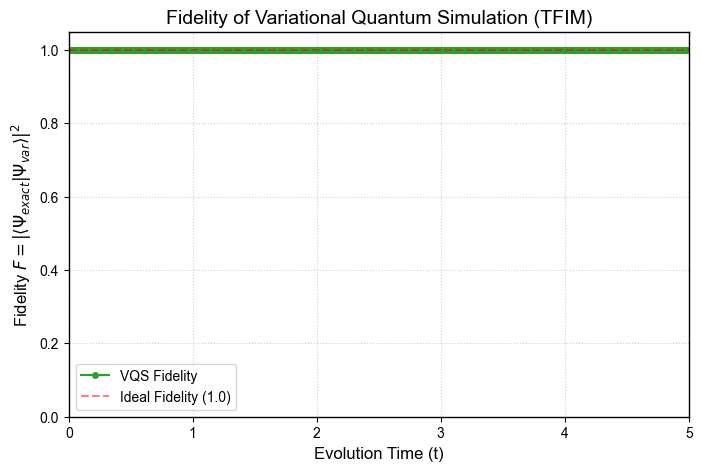

In [47]:
import matplotlib.pyplot as plt

def plot_fidelity(time_points, fidelities):
    plt.figure(figsize=(8, 5), dpi=100)
    
    # Plot the fidelity curve
    plt.plot(time_points, fidelities, 'o-', color='#2ca02c', label='VQS Fidelity', markersize=4)
    
    # Plot the ideal reference line (Fidelity = 1)
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Ideal Fidelity (1.0)')
    
    # Set the axis limits
    plt.ylim(0, 1.05)  # Extend slightly above 1.0 to keep the topmost points visible
    plt.xlim(time_points[0], time_points[-1])
    
    # Add axis labels and a title
    plt.xlabel('Evolution Time (t)', fontsize=12)
    plt.ylabel('Fidelity $F = |\\langle \\Psi_{exact} | \\Psi_{var} \\rangle|^2$', fontsize=12)
    plt.title('Fidelity of Variational Quantum Simulation (TFIM)', fontsize=14)
    
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')
    
    plt.show()

# Call the plotting function
plot_fidelity(time_points, fidelities)

# ITE-NOVQS

In [31]:
# Parameters
Ns = 3
params = init_params(Nq, n_blocks, n_layers, Ns, method=init_dist, seed=42)

coeffs_a = jnp.ones((Ns,))  # 
coeffs_a = coeffs_a.at[0].set(1.0)
coeffs_b = jnp.zeros((Ns,)) 
coeffs_init = coeffs_a * jnp.exp(1j * coeffs_b)
params_coeffs = jnp.concatenate([params, coeffs_a, coeffs_b])  # (n_params + Ns * 2,)

# 1. Instantiate
evolver = MultiStateEvolver(circuit, eigvals, eigvecs, Nq, Ns, reg=1e-8)


states = circuits_fn(params.reshape(Ns, -1))  # (Ns, dim)
psi0 = coeffs_init @ states         # (dim,)
norm = jnp.linalg.norm(psi0)
psi0 = psi0 / norm
eig_coeffs = eigvecs.conj().T @ psi0
print(jnp.abs(eig_coeffs)**2)

[4.51340713e-01 2.61031907e-04 6.67851924e-04 6.57431700e-06
 3.85923723e-01 2.23085424e-05 1.96871333e-04 3.08112972e-05
 1.15681934e-04 3.92709679e-06 7.01274596e-05 6.31695253e-05
 7.82870623e-34 4.80969167e-33 3.31986346e-34 9.09572094e-33
 8.71633682e-34 3.76815495e-34 1.41234780e-32 2.51181395e-37
 3.69241722e-06 9.94739001e-07 1.32322550e-08 2.28603069e-07
 2.58751477e-08 1.72423420e-33 4.91835346e-32 2.38831508e-33
 2.07852989e-33 6.69841307e-33 9.46863927e-33 1.13585725e-32
 5.79088739e-33 1.02988195e-33 1.97976898e-32 1.63904826e-06
 3.52816233e-06 2.79779674e-06 9.80644243e-05 1.90821780e-06
 3.85103667e-05 1.45460190e-30 1.44520630e-32 2.98852053e-07
 1.25863079e-05 3.48045651e-33 2.85742314e-32 2.63935675e-32
 3.79447703e-32 9.94706210e-02 4.32219492e-04 6.29873199e-04
 3.05054217e-05 1.58317319e-08 1.62893343e-03 3.44260364e-31
 5.25384815e-30 1.03627865e-30 3.96486678e-34 8.98502395e-34
 5.83474401e-31 2.97782041e-32 6.49863339e-35 4.02922034e-33
 5.95636167e-34 1.288980

In [32]:
# Simulation parameters
T = 20.0
dt = 0.005
steps = int(T / dt)

time_points = jnp.zeros(steps + 1)
trajectory = jnp.zeros((len(params_coeffs), steps + 1))  

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params_coeffs)

# Time-stepping loop
for i in tqdm(range(steps), desc="Imaginary Time Evolution"):

    t = i * dt
    params_coeffs = rk4_step(evolver.theta_dot_ite, t, params_coeffs, dt) 

    time_points = time_points.at[i + 1].set(t + dt)           # Time points
    trajectory = trajectory.at[:, i + 1].set(params_coeffs)   # Parameter trajectory shape=(n_params_coeffs, n_time_points)

Real Time Evolution: 100%|██████████| 4000/4000 [02:04<00:00, 32.13it/s] 


## Energies

In [33]:
# 1. Prepare the exact solution
ite_solver = exactITE(eigvals, eigvecs, eig_coeffs)

# 2. Instantiate the calculator (assuming Ns=4)
energy_calc = MultiStateEnergyCalculator(circuit, ite_solver, H_mat, Ns)

# 3. Run the batched calculation
# Assume trajectory contains the evolved parameters with shape (n_params, steps)
params_all = trajectory.T
energies_vqs, energies_ite = energy_calc.compute_batched(params_all, time_points, batch_size=100)

Computing Energy: 100%|██████████| 41/41 [00:05<00:00,  7.54it/s]


## Save data

In [322]:
if not os.path.exists("data"):
    os.makedirs("data")
file_path = f"data/NOVQS-ITE-energies-{model_name}-dist={distance}-Nq={Nq}-T={T}-L={n_layers}-B={n_blocks}-Ns={Ns}-{init_state}-{init_dist}.npy"

data_to_save = {
    "energies_vqs": energies_vqs,
    "energies_ite": energies_ite,
    "Eg": Eg,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

## Plot

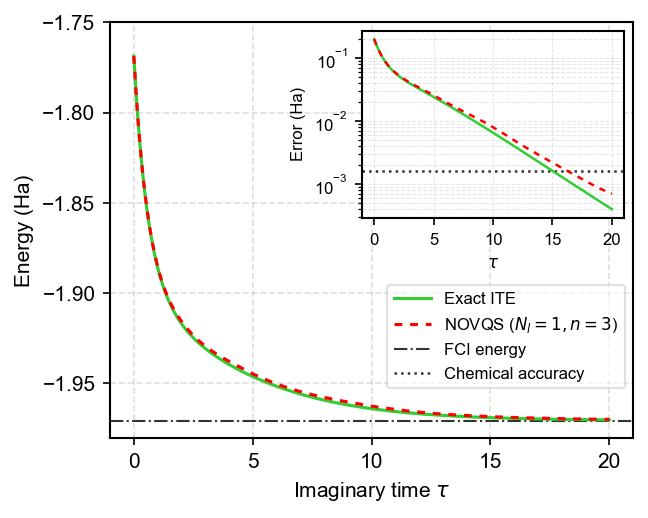

In [34]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1. Set the global plot style (consistent with the existing code)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.0

# Example input data (replace with your own data for actual use)


# Calculate the errors
error_vqs = jnp.abs(energies_vqs - Eg)
error_ite = jnp.abs(energies_ite - Eg)

# 2. Create the figure (4.5x3.6, matching the existing code)
fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)

# 3. Main plot: energy evolution

# Plot Exact ITE (solid line)
line_ite = ax.plot(time_points, energies_ite, '-', color='limegreen', linewidth=1.5, 
        label='Exact ITE')

# Plot VQS (points or a thin line; a line is recommended for a consistent style)
line_vqs = ax.plot(time_points, energies_vqs, ls=(0, (2.5, 2.5)), color='red', linewidth=1.5, 
        label='NOVQS ($N_l=1, n=3$)')

# Plot the ground-state energy reference line (red dashed line, matching the NOVQS style)
line_gs = ax.axhline(y=Eg, color='black', ls='-.', linewidth=1.0, label='FCI energy', alpha=0.8, zorder=1)

# 4. Format the main plot (match ticks, labels, and font sizes)
ax.set_xlabel('Imaginary time $\\tau$', fontsize=10)
ax.set_ylabel('Energy (Ha)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# ==========================================
# 5. Add an inset showing the error on a logarithmic scale
# ==========================================
# Relative position [left, bottom, width, height]; place near the lower left to avoid the upper-right legend
ax_ins = ax.inset_axes([0.482, 0.53, 0.5, 0.45])

# Chemical-accuracy reference line

ax_ins.semilogy(time_points, error_ite, '-', color='limegreen', linewidth=1.2)
ax_ins.semilogy(time_points, error_vqs, ls=(0, (2.5, 2.5)), color='red', linewidth=1.2)

line_ca = ax_ins.axhline(y=1.6e-3, color='black', linestyle=':', linewidth=1.2, label='Chemical accuracy', alpha=0.8, zorder=1)

# Format the inset
ax.set_yticks([-1.75, -1.80, -1.85, -1.90, -1.95])
ax_ins.set_xlabel('$\\tau$', fontsize=8)
ax_ins.set_ylabel('Error (Ha)', fontsize=8)
ax_ins.tick_params(axis='both', which='major', labelsize=8)
ax_ins.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# 1. Get all legend handles and labels from the main plot
handles, labels = ax.get_legend_handles_labels()
handles.append(line_ca)
labels.append('Chemical accuracy')
ax.legend(handles=handles, labels=labels, handlelength=2.2, loc='lower right', bbox_to_anchor=(1.0, 0.1), fontsize=8, framealpha=0.6)

# 6. Save and display
#plt.savefig(f"fig/H4_square-dist=1.28-energy-novqs.pdf", bbox_inches='tight')
plt.show()


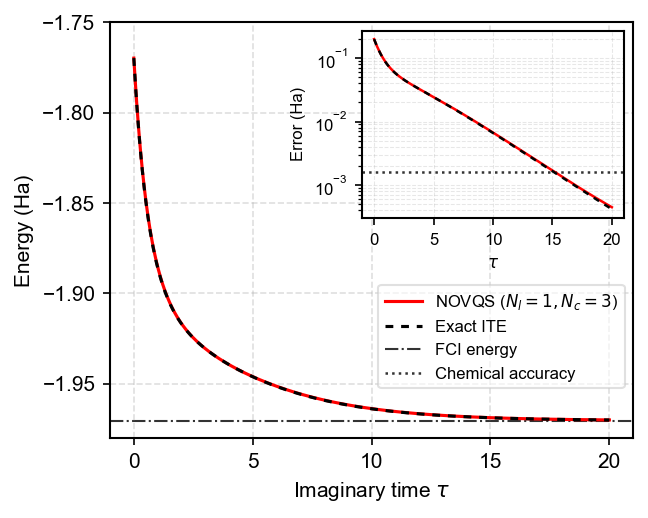

In [5]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1. Set the global plot style (consistent with the existing code)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.0

# Example input data (replace with your own data for actual use)
# time_points, energies_vqs, energies_ite, Eg
file_path = f"data/NOVQS-ITE-energies-H4_square-dist=1.28-Nq=8-T=20.0-L=4-B=1-Ns=3-HF-Perturbation.npy"
data = jnp.load(file_path, allow_pickle=True).item()
energies_vqs = data['energies_vqs']
energies_ite = data['energies_ite']
Eg = data['Eg']
time_points = data['time_points']


# Calculate the errors
error_vqs = jnp.abs(energies_vqs - Eg)
error_ite = jnp.abs(energies_ite - Eg)

# 2. Create the figure (4.5x3.6, matching the existing code)
fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)

# 3. Main plot: energy evolution

# Plot VQS (points or a thin line; a line is recommended for a consistent style)
line_vqs = ax.plot(time_points, energies_vqs, '-', color='red', linewidth=1.5, 
        label='NOVQS ($N_l=1, N_c=3$)')

# Plot Exact ITE (solid line)
line_ite = ax.plot(time_points, energies_ite, ls=(0, (2.5, 2.5)), color='black', linewidth=1.5, 
        label='Exact ITE')


# Plot the ground-state energy reference line (red dashed line, matching the NOVQS style)
line_gs = ax.axhline(y=Eg, color='black', ls='-.', linewidth=1.0, label='FCI energy', alpha=0.8, zorder=1)

# 4. Format the main plot (match ticks, labels, and font sizes)
ax.set_xlabel('Imaginary time $\\tau$', fontsize=10)
ax.set_ylabel('Energy (Ha)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# ==========================================
# 5. Add an inset showing the error on a logarithmic scale
# ==========================================
# Relative position [left, bottom, width, height]; place near the lower left to avoid the upper-right legend
ax_ins = ax.inset_axes([0.482, 0.53, 0.5, 0.45])

# Chemical-accuracy reference line

ax_ins.semilogy(time_points, error_vqs, '-', color='red', linewidth=1.2)
ax_ins.semilogy(time_points, error_ite, ls=(0, (2.5, 2.5)), color='black', linewidth=1.2)

line_ca = ax_ins.axhline(y=1.6e-3, color='black', linestyle=':', linewidth=1.2, label='Chemical accuracy', alpha=0.8, zorder=1)

# Format the inset
ax.set_yticks([-1.75, -1.80, -1.85, -1.90, -1.95])
ax_ins.set_xlabel('$\\tau$', fontsize=8)
ax_ins.set_ylabel('Error (Ha)', fontsize=8)
ax_ins.tick_params(axis='both', which='major', labelsize=8)
ax_ins.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# 1. Get all legend handles and labels from the main plot
handles, labels = ax.get_legend_handles_labels()
handles.append(line_ca)
labels.append('Chemical accuracy')
ax.legend(handles=handles, labels=labels, handlelength=2.2, loc='lower right', bbox_to_anchor=(1.0, 0.1), fontsize=8, framealpha=0.6)

# 6. Save and display
#plt.savefig(f"fig/H4_square-dist=1.28-energy-novqs.pdf", bbox_inches='tight')
plt.show()
